# Design Patent Retrieval Evaluation
벡터DB 검색 품질 평가: Recall@K, MRR, Per-query Rank

## 0. 라이브러리 설치 및 임포트

In [3]:
import re, json, os
from pathlib import Path
import numpy as np
import cv2
import torch
import clip
from PIL import Image
from transformers import AutoImageProcessor, AutoModel, AutoProcessor
import chromadb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'AppleGothic'


/opt/miniconda3/envs/final_develop/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 0-1. 모델 로드

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

clip_model, clip_preprocess = clip.load("ViT-B/32", device=device)
print("CLIP 로드 완료")

dinov2_processor = AutoImageProcessor.from_pretrained("facebook/dinov2-large")
dinov2_model     = AutoModel.from_pretrained("facebook/dinov2-large").to(device)
dinov2_model.eval()
print("DINOv2-Large 로드 완료")

siglip_processor = AutoProcessor.from_pretrained("google/siglip-so400m-patch14-384")
siglip_model     = AutoModel.from_pretrained("google/siglip-so400m-patch14-384").to(device)
siglip_model.eval()
print("SigLIP-SO400M 로드 완료")


Device: cpu
CLIP 로드 완료


Loading weights: 100%|██████████| 439/439 [00:00<00:00, 8092.41it/s]


DINOv2-Large 로드 완료


Loading weights: 100%|██████████| 888/888 [00:00<00:00, 9274.44it/s]

SigLIP-SO400M 로드 완료


In [5]:
def to_sketch(pil_image):
    img_array = np.array(pil_image.convert('L'))
    blurred   = cv2.GaussianBlur(img_array, (5, 5), 0)
    edges     = cv2.Canny(blurred, 30, 100)
    edges     = cv2.bitwise_not(edges)
    return Image.fromarray(edges).convert('RGB')

def _normalize(vec):
    arr  = np.array(vec, dtype=np.float64)
    norm = np.linalg.norm(arr)
    return (arr / norm).tolist() if norm > 0 else vec

def embed_clip(pil_image):
    tensor = clip_preprocess(pil_image).unsqueeze(0).to(device)
    with torch.no_grad():
        vec = clip_model.encode_image(tensor).cpu().numpy()
    return _normalize(vec[0].tolist())

def embed_dinov2(pil_image):
    inputs = dinov2_processor(images=pil_image, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = dinov2_model(**inputs)
    return _normalize(outputs.last_hidden_state[:, 0, :].cpu().numpy()[0].tolist())

def embed_siglip(pil_image):
    inputs = siglip_processor(images=pil_image, return_tensors="pt").to(device)
    with torch.no_grad():
        output = siglip_model.get_image_features(**inputs)
    if hasattr(output, 'pooler_output') and output.pooler_output is not None:
        vec = output.pooler_output
    elif hasattr(output, 'last_hidden_state'):
        vec = output.last_hidden_state[:, 0, :]
    else:
        vec = output
    return _normalize(vec.cpu().numpy()[0].tolist())

def embed_image(pil_image, model_type):
    if model_type == 'clip':    return embed_clip(pil_image)
    if model_type == 'dinov2':  return embed_dinov2(pil_image)
    if model_type == 'siglip':  return embed_siglip(pil_image)
    raise ValueError(f"Unknown model_type: {model_type}")


## 1. 설정

In [6]:
DATASET_DIR    = "/Users/nanahyun/Documents/GitHub/final_develop/design/성능 테스트/dataset"
EVAL_JSON      = os.path.join(DATASET_DIR, "eval.json")
QUERY_DIR      = os.path.join(DATASET_DIR, "quries")   # 실제 폴더명
ANSWER_DIR     = os.path.join(DATASET_DIR, "answer")
CHROMA_DB_PATH = os.path.join(DATASET_DIR, "chroma_eval_db")

# 컬렉션 정의: (collection_name, model_type, is_sketch)
COLLECTIONS = [
    ("design_original_eval_clip",    "clip",    False),
    ("design_original_eval_dinov2",  "dinov2",  False),
    ("design_original_eval_siglip",  "siglip",  False),
    ("design_sketch_eval_clip",      "clip",    True),
    ("design_sketch_eval_dinov2",    "dinov2",  True),
    ("design_sketch_eval_siglip",    "siglip",  True),
]

TOP_K_LIST    = [5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
MAX_K         = max(TOP_K_LIST)
QUALITATIVE_K = 20


## 2. 데이터 로드

In [8]:
def load_json_with_comments(path):
    """// 주석 제거 후 JSON 파싱. 최상위가 배열이 아니면 자동으로 감싸기."""
    with open(path, "r", encoding="utf-8") as f:
        text = f.read()
    text = re.sub(r'//[^\n]*', '', text)
    text = text.strip()
    if not text.startswith('['):
        text = '[' + text + ']'
    text = re.sub(r',\s*([}\]])', r'\1', text)
    return json.loads(text)

eval_data = load_json_with_comments(EVAL_JSON)

print(f"총 쿼리 수: {len(eval_data)}")
print("\n첫 번째 항목 예시:")
print(json.dumps(eval_data[0], indent=2, ensure_ascii=False))


총 쿼리 수: 13

첫 번째 항목 예시:
{
  "query_id": "Q001",
  "application_number": "3020140047287",
  "query_images": [
    "queries/3020140047287_1.png"
  ],
  "legal_basis": "33조2항",
  "answer_images": [
    "answers/3020140047287_1.png"
  ]
}


## 3. 평가 실행

In [9]:
def resolve_query_path(eval_path):
    """eval.json의 query 경로 → 실제 파일 경로 (확장자 .jpg/.png 자동 탐색)"""
    stem = Path(eval_path).stem
    for ext in ['.jpg', '.png', '.jpeg']:
        p = Path(QUERY_DIR) / (stem + ext)
        if p.exists():
            return str(p)
    raise FileNotFoundError(f"Query image not found for stem={stem!r} in {QUERY_DIR}")

def get_answer_db_ids(answer_images, model_type):
    """eval.json의 answer 경로 → DB에 저장된 ID 집합 (answer_{model}_{stem})"""
    return {f"answer_{model_type}_{Path(p).stem}" for p in answer_images}


chroma_client = chromadb.PersistentClient(path=CHROMA_DB_PATH)
all_results   = {}  # collection_name → list of result dicts

for col_name, model_type, is_sketch in COLLECTIONS:
    print(f"\n{'='*55}")
    print(f"평가: {col_name}  (model={model_type}, sketch={is_sketch})")
    print(f"{'='*55}")

    collection = chroma_client.get_collection(col_name)
    results    = []

    for item in eval_data:
        query_id      = item["query_id"]
        app_num       = item["application_number"]
        legal_basis   = item["legal_basis"]
        query_images  = item["query_images"]
        answer_images = item["answer_images"]

        answer_db_ids = get_answer_db_ids(answer_images, model_type)

        # 쿼리 이미지 로드 — sketch DB일 때 to_sketch 적용
        query_file = resolve_query_path(query_images[0])
        pil_image  = Image.open(query_file).convert("RGB")
        if is_sketch:
            pil_image = to_sketch(pil_image)

        query_vec = embed_image(pil_image, model_type)

        search_res    = collection.query(query_embeddings=[query_vec],
                                         n_results=MAX_K,
                                         include=["distances"])
        retrieved_ids = search_res['ids'][0]

        # Recall@K
        recall_at_k = {}
        for k in TOP_K_LIST:
            hit = len(answer_db_ids & set(retrieved_ids[:k]))
            recall_at_k[k] = hit / len(answer_db_ids) if answer_db_ids else 0.0

        # Rank / MRR
        first_hit_rank = next(
            (rank for rank, rid in enumerate(retrieved_ids, 1) if rid in answer_db_ids),
            None
        )
        reciprocal_rank = (1 / first_hit_rank) if first_hit_rank else 0.0

        results.append({
            "query_id":           query_id,
            "application_number": app_num,
            "legal_basis":        legal_basis,
            "answer_count":       len(answer_db_ids),
            "first_hit_rank":     first_hit_rank,
            "reciprocal_rank":    reciprocal_rank,
            **{f"recall@{k}": recall_at_k[k] for k in TOP_K_LIST},
        })

        print(f"  [{query_id}] rank={first_hit_rank}  "
              f"R@10={recall_at_k[10]:.2f}  R@20={recall_at_k[20]:.2f}")

    all_results[col_name] = results
    print(f"  → {len(results)}건 완료")



평가: design_original_eval_clip  (model=clip, sketch=False)
  [Q001] rank=None  R@10=0.00  R@20=0.00
  [Q002] rank=None  R@10=0.00  R@20=0.00
  [Q003] rank=None  R@10=0.00  R@20=0.00
  [Q004] rank=1  R@10=1.00  R@20=1.00
  [Q005] rank=None  R@10=0.00  R@20=0.00
  [Q006] rank=None  R@10=0.00  R@20=0.00
  [Q007] rank=1  R@10=0.50  R@20=0.50
  [Q008] rank=None  R@10=0.00  R@20=0.00
  [Q009] rank=None  R@10=0.00  R@20=0.00
  [Q010] rank=None  R@10=0.00  R@20=0.00
  [Q011] rank=None  R@10=0.00  R@20=0.00
  [Q012] rank=None  R@10=0.00  R@20=0.00
  [Q013] rank=None  R@10=0.00  R@20=0.00
  → 13건 완료

평가: design_original_eval_dinov2  (model=dinov2, sketch=False)
  [Q001] rank=57  R@10=0.00  R@20=0.00
  [Q002] rank=None  R@10=0.00  R@20=0.00
  [Q003] rank=None  R@10=0.00  R@20=0.00
  [Q004] rank=1  R@10=1.00  R@20=1.00
  [Q005] rank=None  R@10=0.00  R@20=0.00
  [Q006] rank=None  R@10=0.00  R@20=0.00
  [Q007] rank=1  R@10=1.00  R@20=1.00
  [Q008] rank=1  R@10=1.00  R@20=1.00
  [Q009] rank=None  R@1

## 4. 결과 요약

In [10]:
from IPython.display import display

summary_rows = []

for col_name, model_type, is_sketch in COLLECTIONS:
    df          = pd.DataFrame(all_results[col_name])
    mrr         = df["reciprocal_rank"].mean()
    mean_recall = {k: df[f"recall@{k}"].mean() for k in TOP_K_LIST}
    db_type     = "sketch" if is_sketch else "original"

    print(f"\n[{col_name}]  MRR={mrr:.4f}")
    for k in TOP_K_LIST:
        print(f"  Recall@{k:>3}: {mean_recall[k]:.4f}")

    summary_rows.append({
        "collection": col_name,
        "model":      model_type,
        "db_type":    db_type,
        "MRR":        round(mrr, 4),
        **{f"Recall@{k}": round(mean_recall[k], 4) for k in TOP_K_LIST},
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)



[design_original_eval_clip]  MRR=0.1538
  Recall@  5: 0.1154
  Recall@ 10: 0.1154
  Recall@ 20: 0.1154
  Recall@ 30: 0.1154
  Recall@ 40: 0.1154
  Recall@ 50: 0.1154
  Recall@ 60: 0.1154
  Recall@ 70: 0.1154
  Recall@ 80: 0.1154
  Recall@ 90: 0.1154
  Recall@100: 0.1154

[design_original_eval_dinov2]  MRR=0.2349
  Recall@  5: 0.2308
  Recall@ 10: 0.2308
  Recall@ 20: 0.2308
  Recall@ 30: 0.2692
  Recall@ 40: 0.2692
  Recall@ 50: 0.2692
  Recall@ 60: 0.3462
  Recall@ 70: 0.3462
  Recall@ 80: 0.3462
  Recall@ 90: 0.3462
  Recall@100: 0.3462

[design_original_eval_siglip]  MRR=0.1209
  Recall@  5: 0.1154
  Recall@ 10: 0.1154
  Recall@ 20: 0.1538
  Recall@ 30: 0.1538
  Recall@ 40: 0.1538
  Recall@ 50: 0.1538
  Recall@ 60: 0.1538
  Recall@ 70: 0.1923
  Recall@ 80: 0.1923
  Recall@ 90: 0.1923
  Recall@100: 0.1923

[design_sketch_eval_clip]  MRR=0.0784
  Recall@  5: 0.0385
  Recall@ 10: 0.0769
  Recall@ 20: 0.0769
  Recall@ 30: 0.0769
  Recall@ 40: 0.0769
  Recall@ 50: 0.0769
  Recall@ 60: 0

,collection,model,db_type,MRR,Recall@5,Recall@10,Recall@20,Recall@30,Recall@40,Recall@50,Recall@60,Recall@70,Recall@80,Recall@90,Recall@100
0,design_original_eval_clip,clip,original,0.1538,0.1154,0.1154,0.1154,0.1154,0.1154,0.1154,0.1154,0.1154,0.1154,0.1154,0.1154
1,design_original_eval_dinov2,dinov2,original,0.2349,0.2308,0.2308,0.2308,0.2692,0.2692,0.2692,0.3462,0.3462,0.3462,0.3462,0.3462
2,design_original_eval_siglip,siglip,original,0.1209,0.1154,0.1154,0.1538,0.1538,0.1538,0.1538,0.1538,0.1923,0.1923,0.1923,0.1923
3,design_sketch_eval_clip,clip,sketch,0.0784,0.0385,0.0769,0.0769,0.0769,0.0769,0.0769,0.1538,0.1538,0.1538,0.1538,0.1538
4,design_sketch_eval_dinov2,dinov2,sketch,0.1033,0.0769,0.1923,0.1923,0.2692,0.2692,0.2692,0.2692,0.2692,0.3077,0.3077,0.3077
5,design_sketch_eval_siglip,siglip,sketch,0.1428,0.1538,0.1538,0.2692,0.2692,0.2692,0.2692,0.3462,0.3462,0.3462,0.3462,0.4231


## 5. Recall@K 곡선 시각화

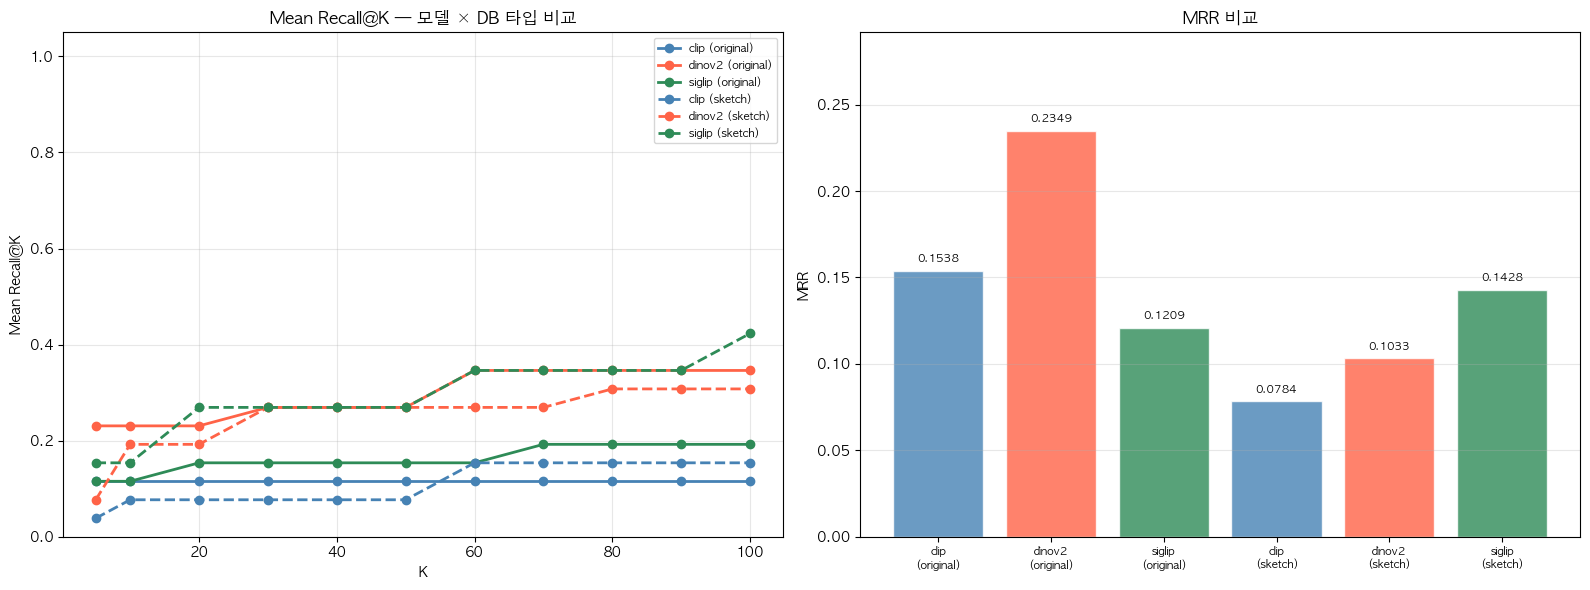

recall_curves.png 저장 완료


In [11]:
colors = {"clip": "steelblue", "dinov2": "tomato", "siglip": "seagreen"}
styles = {"original": "-", "sketch": "--"}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- (왼쪽) 모델별 Recall@K 곡선 (original vs sketch 비교) ---
ax = axes[0]
for col_name, model_type, is_sketch in COLLECTIONS:
    df          = pd.DataFrame(all_results[col_name])
    mean_recall = [df[f"recall@{k}"].mean() for k in TOP_K_LIST]
    db_type     = "sketch" if is_sketch else "original"
    label       = f"{model_type} ({db_type})"
    ax.plot(TOP_K_LIST, mean_recall,
            marker="o", linewidth=2,
            color=colors[model_type],
            linestyle=styles[db_type],
            label=label)

ax.set_xlabel("K")
ax.set_ylabel("Mean Recall@K")
ax.set_title("Mean Recall@K — 모델 × DB 타입 비교")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- (오른쪽) MRR 막대 그래프 ---
ax2 = axes[1]
bar_labels = [f"{m}\n({t})" for _, m, s in COLLECTIONS
              for t in ["sketch" if s else "original"]]
bar_labels = [f"{m}\n({'sketch' if s else 'original'})"
              for _, m, s in COLLECTIONS]
mrr_values = [pd.DataFrame(all_results[c])["reciprocal_rank"].mean()
              for c, _, _ in COLLECTIONS]
bar_colors = [colors[m] for _, m, _ in COLLECTIONS]
ax2.bar(range(len(bar_labels)), mrr_values, color=bar_colors, alpha=0.8, edgecolor="white")
ax2.set_xticks(range(len(bar_labels)))
ax2.set_xticklabels(bar_labels, fontsize=8)
ax2.set_ylabel("MRR")
ax2.set_title("MRR 비교")
ax2.set_ylim(0, max(mrr_values) * 1.2 + 0.01)
ax2.grid(axis="y", alpha=0.3)
for i, v in enumerate(mrr_values):
    ax2.text(i, v + 0.005, f"{v:.4f}", ha="center", fontsize=8)

plt.tight_layout()
out_dir = os.path.join(DATASET_DIR, "eval_results")
os.makedirs(out_dir, exist_ok=True)
plt.savefig(os.path.join(out_dir, "recall_curves.png"), dpi=150, bbox_inches="tight")
plt.show()
print("recall_curves.png 저장 완료")


## 6. 정성 확인 — 쿼리별 Top-20 검색 결과

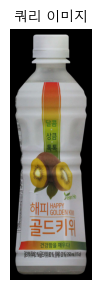

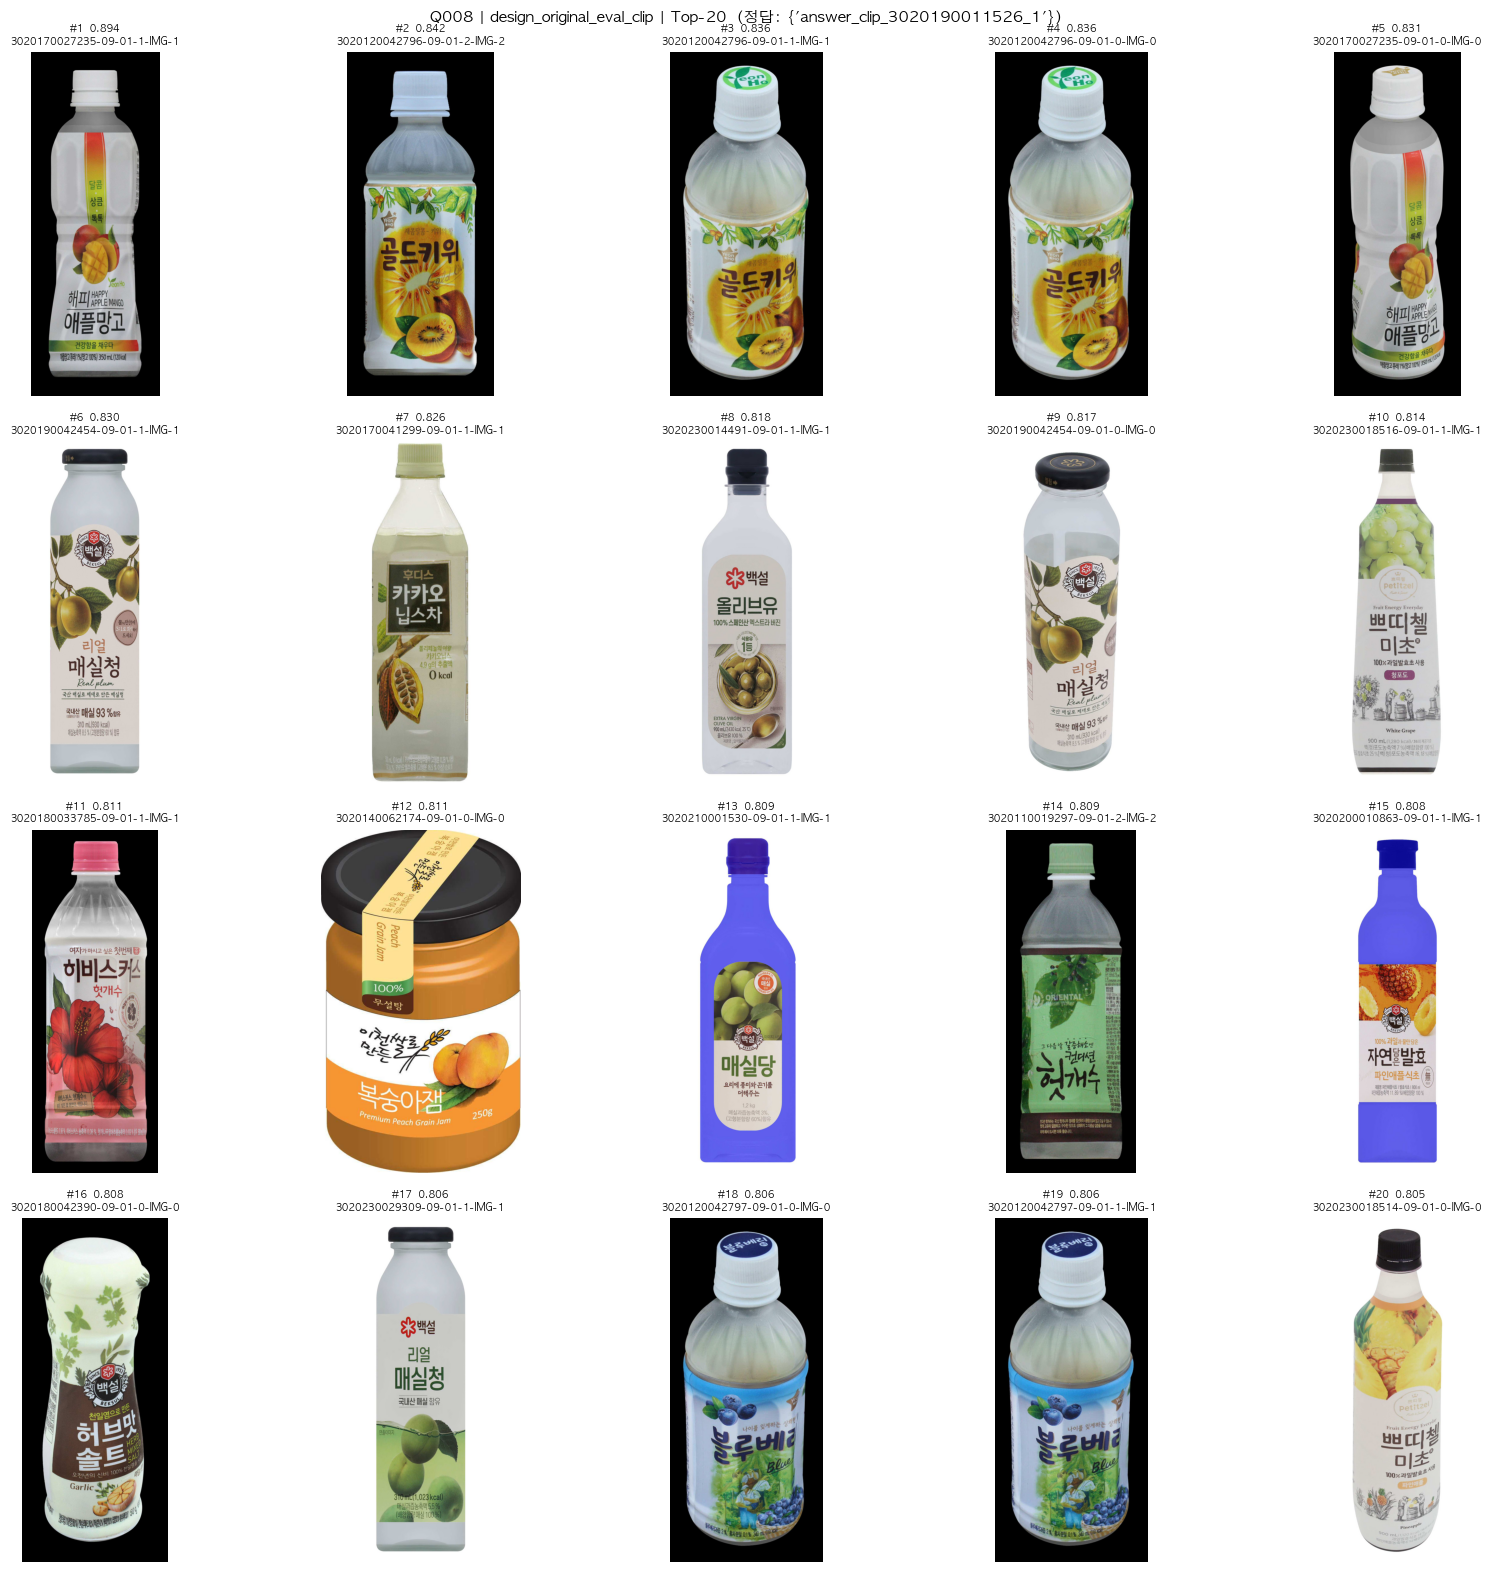

In [23]:
import requests
from io import BytesIO

def load_result_image(img_id, meta):
    """answer 이미지는 로컬 파일, 그 외는 imagePath URL로 로드"""
    if img_id.startswith("answer_"):
        path = os.path.join(ANSWER_DIR, meta.get("filename", ""))
        try:
            return Image.open(path).convert("RGB")
        except Exception:
            return None
    url = meta.get("imagePath", "")
    if not url:
        return None
    try:
        resp = requests.get(url, timeout=10)
        resp.raise_for_status()
        return Image.open(BytesIO(resp.content)).convert("RGB")
    except Exception:
        return None

def show_eval_results(query_pil, top_results, answer_db_ids, metadatas, title, cols=5):
    n    = len(top_results)
    rows = (n + cols - 1) // cols

    # 쿼리 이미지 먼저 출력
    fig_q, ax_q = plt.subplots(1, 1, figsize=(3, 3))
    ax_q.imshow(query_pil)
    ax_q.set_title("쿼리 이미지", fontsize=10)
    ax_q.axis('off')
    plt.tight_layout()
    plt.show()

    # 검색 결과 그리드
    fig = plt.figure(figsize=(cols * 3.5, rows * 4))
    fig.suptitle(title, fontsize=11, fontweight='bold')

    for i, ((img_id, dist), meta) in enumerate(zip(top_results, metadatas)):
        ax  = fig.add_subplot(rows, cols, i + 1)
        img = load_result_image(img_id, meta)
        if img:
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, '이미지\n없음', ha='center', va='center',
                    transform=ax.transAxes, fontsize=9)

        is_ans = img_id in answer_db_ids
        score  = 1 - dist
        mark   = "✅ " if is_ans else ""
        label  = f"#{i+1}  {mark}{score:.3f}\n{img_id}"

        for spine in ax.spines.values():
            spine.set_edgecolor("limegreen" if is_ans else "lightgray")
            spine.set_linewidth(3 if is_ans else 0.5)

        ax.set_title(label, fontsize=7, color="green" if is_ans else "black")
        ax.axis('off')

    plt.tight_layout()
    plt.show()


# ── 확인 설정 (변경 가능) ──────────────────
TARGET_QUERY_ID = "Q008"
TARGET_COL_NAME = "design_original_eval_clip"
# ──────────────────────────────────────────

col_cfg                         = next(c for c in COLLECTIONS if c[0] == TARGET_COL_NAME)
col_name, model_type, is_sketch = col_cfg

target        = next(item for item in eval_data if item["query_id"] == TARGET_QUERY_ID)
answer_db_ids = get_answer_db_ids(target["answer_images"], model_type)

query_file = resolve_query_path(target["query_images"][0])
pil_image  = Image.open(query_file).convert("RGB")
if is_sketch:
    pil_image = to_sketch(pil_image)

query_vec  = embed_image(pil_image, model_type)
collection = chroma_client.get_collection(col_name)
search_res = collection.query(query_embeddings=[query_vec],
                               n_results=QUALITATIVE_K,
                               include=["distances", "metadatas"])

top_results = list(zip(search_res['ids'][0], search_res['distances'][0]))
metadatas   = search_res['metadatas'][0]

title = (f"{TARGET_QUERY_ID} | {col_name} | Top-{QUALITATIVE_K}  "
         f"(정답: {answer_db_ids})")
show_eval_results(pil_image, top_results, answer_db_ids, metadatas, title)


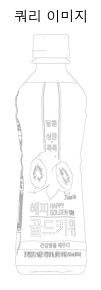

/var/folders/fp/pf5d987j21l49z14fhfcysmw0000gn/T/ipykernel_19053/3000814482.py:59: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) AppleGothic.
  plt.tight_layout()


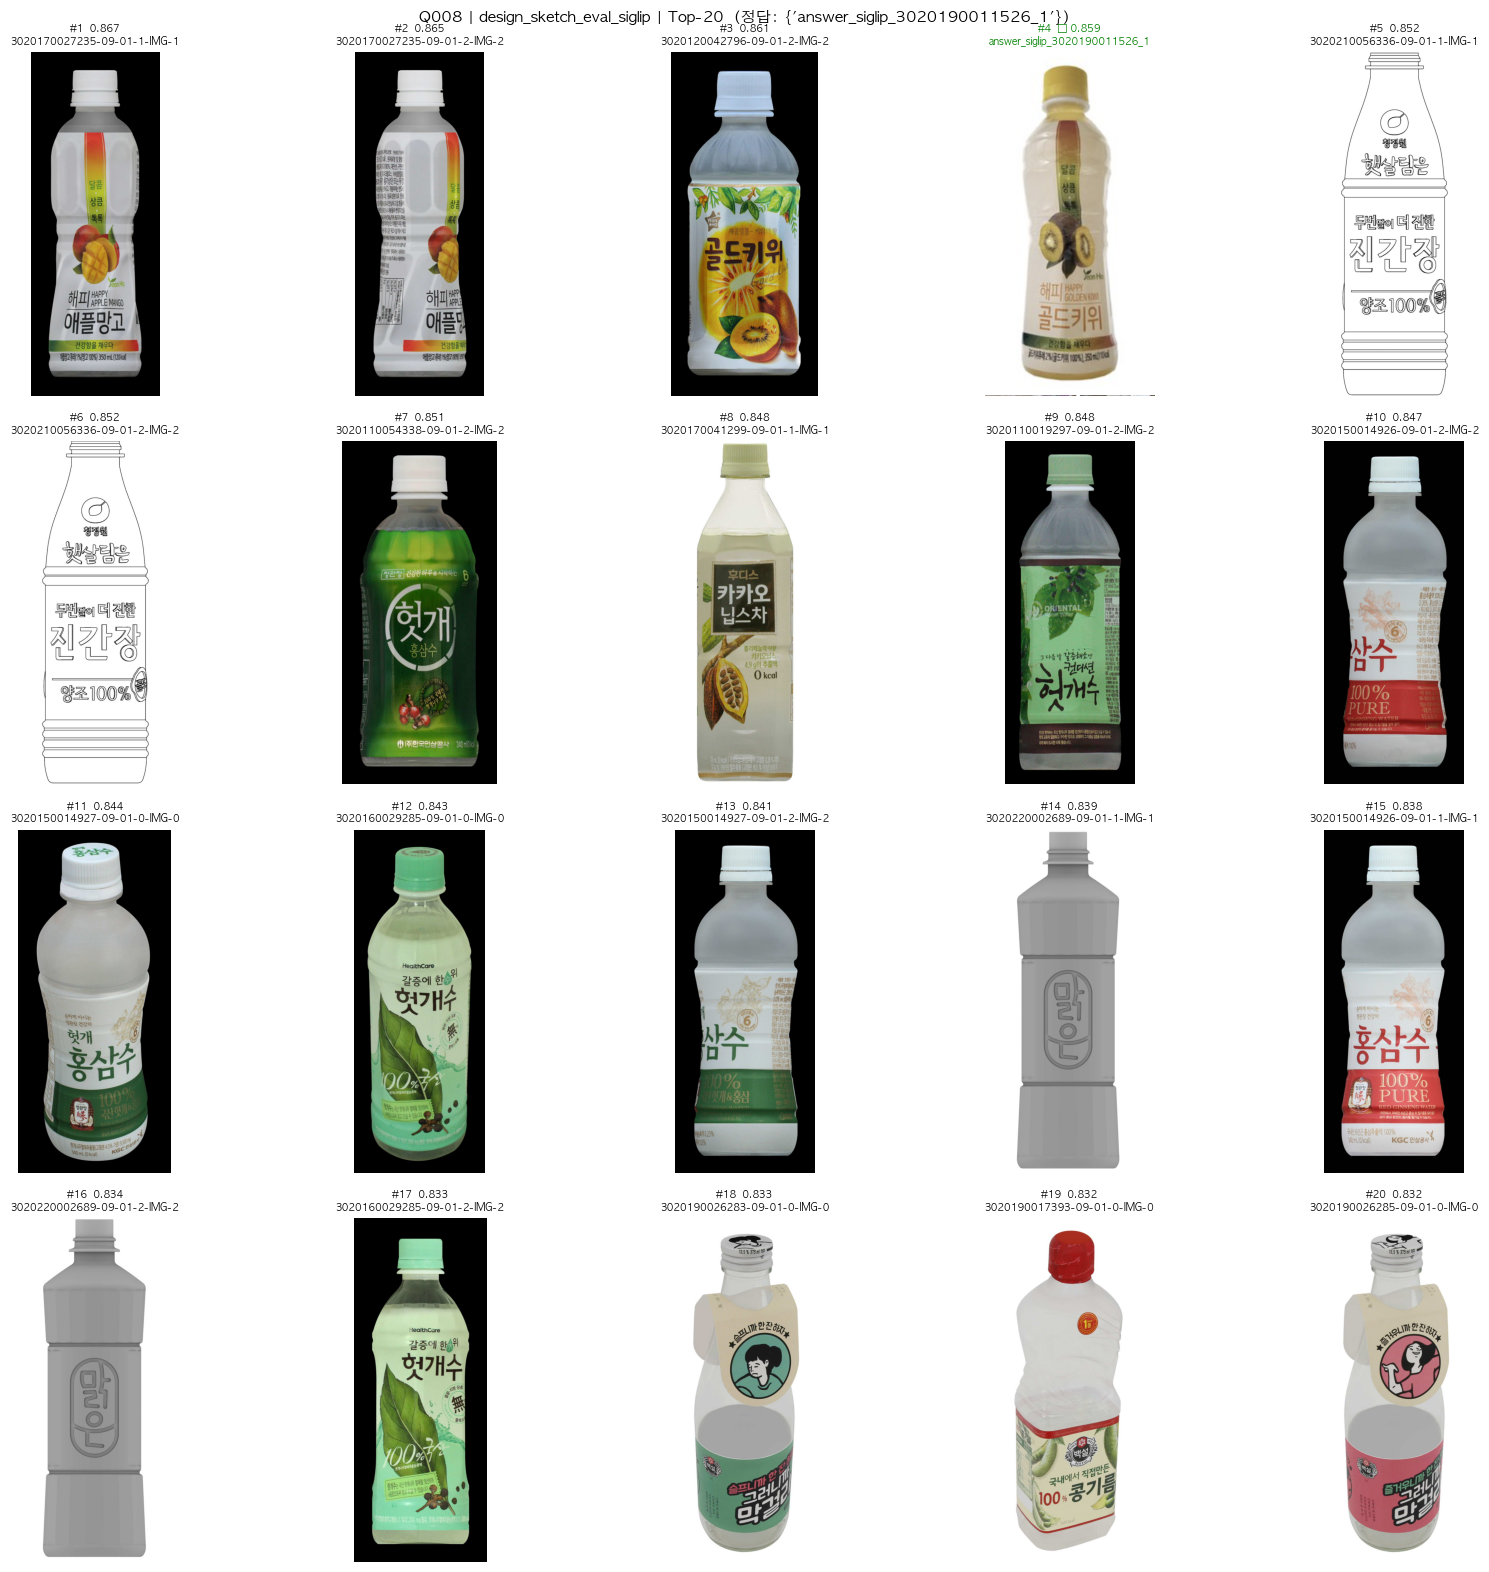

In [24]:
import requests
from io import BytesIO

def load_result_image(img_id, meta):
    """answer 이미지는 로컬 파일, 그 외는 imagePath URL로 로드"""
    if img_id.startswith("answer_"):
        path = os.path.join(ANSWER_DIR, meta.get("filename", ""))
        try:
            return Image.open(path).convert("RGB")
        except Exception:
            return None
    url = meta.get("imagePath", "")
    if not url:
        return None
    try:
        resp = requests.get(url, timeout=10)
        resp.raise_for_status()
        return Image.open(BytesIO(resp.content)).convert("RGB")
    except Exception:
        return None

def show_eval_results(query_pil, top_results, answer_db_ids, metadatas, title, cols=5):
    n    = len(top_results)
    rows = (n + cols - 1) // cols

    # 쿼리 이미지 먼저 출력
    fig_q, ax_q = plt.subplots(1, 1, figsize=(3, 3))
    ax_q.imshow(query_pil)
    ax_q.set_title("쿼리 이미지", fontsize=10)
    ax_q.axis('off')
    plt.tight_layout()
    plt.show()

    # 검색 결과 그리드
    fig = plt.figure(figsize=(cols * 3.5, rows * 4))
    fig.suptitle(title, fontsize=11, fontweight='bold')

    for i, ((img_id, dist), meta) in enumerate(zip(top_results, metadatas)):
        ax  = fig.add_subplot(rows, cols, i + 1)
        img = load_result_image(img_id, meta)
        if img:
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, '이미지\n없음', ha='center', va='center',
                    transform=ax.transAxes, fontsize=9)

        is_ans = img_id in answer_db_ids
        score  = 1 - dist
        mark   = "✅ " if is_ans else ""
        label  = f"#{i+1}  {mark}{score:.3f}\n{img_id}"

        for spine in ax.spines.values():
            spine.set_edgecolor("limegreen" if is_ans else "lightgray")
            spine.set_linewidth(3 if is_ans else 0.5)

        ax.set_title(label, fontsize=7, color="green" if is_ans else "black")
        ax.axis('off')

    plt.tight_layout()
    plt.show()


# ── 확인 설정 (변경 가능) ──────────────────
TARGET_QUERY_ID = "Q008"
TARGET_COL_NAME = "design_sketch_eval_siglip"
# ──────────────────────────────────────────

col_cfg                         = next(c for c in COLLECTIONS if c[0] == TARGET_COL_NAME)
col_name, model_type, is_sketch = col_cfg

target        = next(item for item in eval_data if item["query_id"] == TARGET_QUERY_ID)
answer_db_ids = get_answer_db_ids(target["answer_images"], model_type)

query_file = resolve_query_path(target["query_images"][0])
pil_image  = Image.open(query_file).convert("RGB")
if is_sketch:
    pil_image = to_sketch(pil_image)

query_vec  = embed_image(pil_image, model_type)
collection = chroma_client.get_collection(col_name)
search_res = collection.query(query_embeddings=[query_vec],
                               n_results=QUALITATIVE_K,
                               include=["distances", "metadatas"])

top_results = list(zip(search_res['ids'][0], search_res['distances'][0]))
metadatas   = search_res['metadatas'][0]

title = (f"{TARGET_QUERY_ID} | {col_name} | Top-{QUALITATIVE_K}  "
         f"(정답: {answer_db_ids})")
show_eval_results(pil_image, top_results, answer_db_ids, metadatas, title)

## 7. 결과 저장

In [ ]:
out_dir = os.path.join(DATASET_DIR, "eval_results")
os.makedirs(out_dir, exist_ok=True)

# 컬렉션별 CSV 저장
for col_name, _, _ in COLLECTIONS:
    df       = pd.DataFrame(all_results[col_name])
    out_path = os.path.join(out_dir, f"{col_name}.csv")
    df.to_csv(out_path, index=False, encoding="utf-8-sig")
    print(f"저장: {out_path}")

# 통합 요약 CSV
summary_path = os.path.join(out_dir, "summary.csv")
summary_df.to_csv(summary_path, index=False, encoding="utf-8-sig")
print(f"\n요약 저장: {summary_path}")
print("\n[논문 테이블용 요약]")
print(summary_df[["collection", "model", "db_type", "MRR"] +
                 [f"Recall@{k}" for k in TOP_K_LIST]].to_string(index=False))
